<a href="https://colab.research.google.com/github/bobo33772-blip/AI_study/blob/main/%EB%94%A5%EB%9F%AC%EB%8B%9D_12_1_%EB%84%A4%EC%9D%B4%EB%B2%84_%EC%98%81%ED%99%94%EB%A6%AC%EB%B7%B0%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 파일을 현재폴더에 복사
!cp "/content/drive/MyDrive/AI+X 인공지능/data/nsmc-master.zip" .

In [2]:
!dir

drive  nsmc-master.zip	sample_data


In [3]:
# 압축해제
!unzip -q nsmc-master.zip

In [4]:
# -F 폴더는 / 실행파일은 *
!dir -F

drive/	nsmc-master/  nsmc-master.zip  sample_data/


In [5]:
# -l 파일의 자세한 정보
# -h 파일 크기단위로 보여줌
!dir -Flh nsmc-master

total 38M
drwxr-xr-x 2 root root 4.0K Jun 28  2016 code/
-rw-r--r-- 1 root root 4.7M Jun 28  2016 ratings_test.txt
-rw-r--r-- 1 root root  14M Jun 28  2016 ratings_train.txt
-rw-r--r-- 1 root root  19M Jun 28  2016 ratings.txt
drwxr-xr-x 2 root root 448K Jun 28  2016 raw/
-rw-r--r-- 1 root root 2.6K Jun 28  2016 README.md
-rw-r--r-- 1 root root  36K Jun 28  2016 synopses.json


In [6]:
# 파일 내용 일부만 보기
!head -5 nsmc-master/ratings.txt

id	document	label
8112052	어릴때보고 지금다시봐도 재밌어요ㅋㅋ	1
8132799	디자인을 배우는 학생으로, 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산업이 부러웠는데. 사실 우리나라에서도 그 어려운시절에 끝까지 열정을 지킨 노라노 같은 전통이있어 저와 같은 사람들이 꿈을 꾸고 이뤄나갈 수 있다는 것에 감사합니다.	1
4655635	폴리스스토리 시리즈는 1부터 뉴까지 버릴께 하나도 없음.. 최고.	1
9251303	와.. 연기가 진짜 개쩔구나.. 지루할거라고 생각했는데 몰입해서 봤다.. 그래 이런게 진짜 영화지	1


In [7]:
import pandas as pd
file_tr = "/content/nsmc-master/ratings_train.txt"
file_te = "/content/nsmc-master/ratings_test.txt"
train_data = pd.read_csv(file_tr, sep="\t")
test_data = pd.read_csv(file_te, sep="\t")

In [8]:
print(train_data.shape)
print(test_data.shape)

(150000, 3)
(50000, 3)


In [9]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        150000 non-null  int64 
 1   document  149995 non-null  object
 2   label     150000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.4+ MB


In [10]:
test_data[['document','label']].head()

,document,label
0,굳 ㅋ,1
1,GDNTOPCLASSINTHECLUB,0
2,뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아,0
3,지루하지는 않은데 완전 막장임... 돈주고 보기에는....,0
4,3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??,0


In [11]:
# 비중복 데이터
train_data['document'].nunique() #150000

146182

In [12]:
# 중복데이터 삭제
train_data.drop_duplicates(
    subset=['document'], inplace=True)

train_data['document'].nunique()

146182

In [13]:
train_data.shape

(146183, 3)

In [14]:
train_data['label'].value_counts()

,count
label,
0,73342
1,72841


In [15]:
# 결측치 삭제
train_data = train_data.dropna(how='any') # all
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 146182 entries, 0 to 149999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   id        146182 non-null  int64 
 1   document  146182 non-null  object
 2   label     146182 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.5+ MB


In [16]:
# # 한글만 남기기(알파벳, 공백 삭제)
# # 정규표현식
# eng_txt = 'hi ~hello, nice to meet you~~'
# import re
# # sub(찾는패턴,바꿀글자) 치환
# # re.sub('[^ㄱ-ㅎㅏ-ㅣ가-힣 ]','',eng_txt)
# re.sub('[^a-zA-Z ]','',eng_txt)

In [17]:
# c = '가'
# for i in range(10):
#   print(chr(ord(c)+i),end='')

In [18]:
# 한글만 남기기(알파벳, 공백 삭제)
train_data['document'] = train_data['document'].str.replace('[^ㄱ-ㅎㅏ-ㅣ가-힣 ]',"",regex=True)

In [19]:
train_data[5:]

,id,document,label
5,5403919,막 걸음마 뗀 세부터 초등학교 학년생인 살용영화ㅋㅋㅋ별반개도 아까움,0
6,7797314,원작의 긴장감을 제대로 살려내지못했다,0
7,9443947,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지정말 발로해도 그것보단 낫...,0
8,7156791,액션이 없는데도 재미 있는 몇안되는 영화,1
9,5912145,왜케 평점이 낮은건데 꽤 볼만한데 헐리우드식 화려함에만 너무 길들여져 있나,1
...,...,...,...
149995,6222902,인간이 문제지 소는 뭔죄인가,0
149996,8549745,평점이 너무 낮아서,1
149997,9311800,이게 뭐요 한국인은 거들먹거리고 필리핀 혼혈은 착하다,0
149998,2376369,청춘 영화의 최고봉방황과 우울했던 날들의 자화상,1


In [20]:
# 변환결과 공백만 존재하는 행 찾아 공백들을 삭제
train_data['document'] = train_data['document'].str.replace(
    '^ +',"",regex=True)

In [21]:
train_data.query('document==""  '  )

,id,document,label
404,4221289,,0
412,9509970,,1
470,10147571,,1
584,7117896,,0
593,6478189,,0
...,...,...,...
149309,6715725,,1
149358,6780491,,0
149364,8014701,,1
149630,3508604,,0


In [22]:
train_data = train_data.query(' document != ""  '  )
train_data.shape

(145393, 3)

In [23]:
# test_data로 전처리
# 한글만 남기기(알파벳, 공백 삭제)
test_data['document'] = test_data['document'].str.replace(
    '[^ㄱ-ㅎㅏ-ㅣ가-힣 ]',"",regex=True)

# 변환결과 공백만 존재하는 행 찾아 공백들을 삭제
test_data['document'] = test_data['document'].str.replace(
    '^ +',"",regex=True)

test_data = test_data.query(' document != ""  '  )
test_data.shape

(49578, 3)

In [24]:
# 한글 토큰화
# 형태소분석 후 1개글자이상만 남겨두기
# 형태소 - 의미를 가진 최소의 글자
# 형태소 분석기
# Okt=쉽다(자바설치)   Kmoran=가성비좋음    Mecab=성능최강
!java -version
# Okt 설치 확인
!pip list | grep nlp
# konlp 설치
! pip install konlpy
# 한글 형태소 분석기
from konlpy.tag import Okt
okt = Okt() # 형태소분석기 객체 생성
text = "파이썬으로 형태소 분석했어요"
okt.morphs(text)
text = "파이썬으로 형태소 분석했어요"
okt.pos(text) #품사태깅
okt.nouns(text) # 명사추출
text = "파이썬으로 형태소 분석했어요"
okt.pos(text, norm=True, stem=True) #품사태깅
# Okt 설치 확인
!pip list | grep nlp
# konlp 설치
! pip install konlpy
# 한글 형태소 분석기
from konlpy.tag import Okt
okt = Okt() # 형태소분석기 객체 생성
text = "파이썬으로 형태소 분석했어요"
okt.morphs(text)
text = "파이썬으로 형태소 분석했어요"
okt.pos(text) #품사태깅
okt.nouns(text) # 명사추출
text = "파이썬으로 형태소 분석했어요"
okt.pos(text, norm=True, stem=True) #품사태깅

openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
keras-nlp                                0.26.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.0/438.0 kB 40.5 MB/s eta 0:00:00
keras-nlp                                0.26.0
konlpy                                   0.6.0


[('파이썬', 'Noun'),
 ('으로', 'Josa'),
 ('형태소', 'Noun'),
 ('분석', 'Noun'),
 ('하다', 'Verb')]

In [25]:
#토큰화
# 불용어 제거(의미없는 글자)
stopwords = ['이', '있', '하', '것', '들', '그', '되', '수', '이', '보', '않', '없', '나', '사람', '주', '아니', '등', '같', '우리', '때', '년', '가', '한', '지', '대하', '오', '말', '일', '그렇', '위하']


In [ ]:
from tqdm import tqdm

X_train = []
for s in tqdm(train_data['document']): # [아 더빙 진짜 짜증나네요 목소리.]
  s_token = okt.morphs(s, stem=True) #[(아) (더빙) (진짜) (짜증나네요) (목소리)]
  # 불용어제거.추출한 형태소가 불용어에 있지 않으면
  s_token_stopped = [ word for word in s_token if word not in stopwords ]
  X_train.append(s_token_stopped)

In [ ]:
X_train[:4]

In [ ]:
# 정수인코딩 단어->숫자
import keras
from tensorflow.keras.preprocessing.text import Tokenizer
tok = Tokenizer()
tok.fit_on_texts(X_train) # 단어집합생성

In [ ]:
print(tok.word_index)

In [ ]:
# tok.word_counts # 단어별 빈도수

In [ ]:
# 단어의 빈도수 1개인것 삭제 -> 갯수파악
total_count = len(tok.word_index)
rare_count = 0
for word,count in tok.word_counts.items():
  if count <= 1:
    rare_count += 1

print('rare_count',rare_count)

In [ ]:
print('의미있는것',total_count-rare_count)

In [ ]:
# 의미있는 단어만 추출 num_words 추출할 상위빈도수 개수
tok = Tokenizer(num_words=total_count-rare_count)
tok.fit_on_texts(X_train)
# 정수 시쿼스로 변환
X_train = tok.texts_to_sequences(X_train)

In [36]:
from tqdm import tqdm

#결측치 제거
test_data = test_data.dropna(how='any') # all

X_test = []
for s in tqdm(test_data['document']): # [아 더빙 진짜 짜증나네요 목소리.]
  s_token = okt.morphs(s, stem=True) #[(아) (더빙) (진짜) (짜증나네요) (목소리)]
  # 불용어제거.추출한 형태소가 불용어에 있지 않으면
  s_token_stopped = [ word for word in s_token if word not in stopwords ]
  X_test.append(s_token_stopped)

100%|██████████| 49575/49575 [03:11<00:00, 258.69it/s]


In [37]:
# 정수 시쿼스로 변환
X_test= tok.texts_to_sequences(X_test)
X_test[:5]

[[673, 90],
 [67, 172, 32, 11, 518, 25, 28, 313, 1056, 8, 49, 724, 27],
 [68, 25, 92, 314, 114, 104, 69, 156, 286],
 [21, 27, 119, 2359, 105, 69, 42, 26, 34, 199, 9, 698, 3],
 [204, 3177, 19, 36, 4, 204, 1]]

In [38]:
print('X_train',len(X_train))
print('X_test',len(X_test))

X_train 43007
X_test 49575


In [39]:
y_train = train_data['label']
y_test = test_data['label']

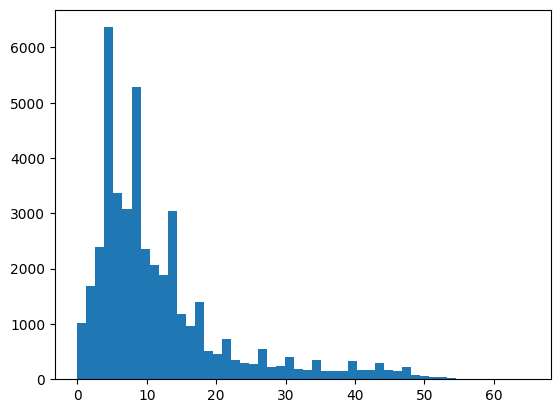

In [40]:
# 패딩을 위해 리뷰문장의길이의 분포 파악
lengths = [len(review) for review in X_train]

import matplotlib.pyplot as plt
plt.hist(lengths, bins=50)
plt.show()

In [41]:
import pandas as pd
pd.Series(lengths).describe()

,0
count,43007.000000
mean,11.808357
std,9.972002
min,0.000000
25%,5.000000
50%,9.000000
75%,14.000000
max,65.000000


In [42]:
# 전체 90%는 문장길이 25단어
pd.Series(lengths).quantile(0.90)

np.float64(25.0)

In [44]:
# pad_sequence() 지정
from keras.preprocessing.sequence import pad_sequences
max_len = 25
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)
#

In [45]:
# 학습

model = keras.Sequential()
model.add(keras.layers.Embedding(total_count-rare_count, 100))
model.add(keras.layers.LSTM(128))
model.add(keras.layers.Dense(1, activation='sigmoid'))

In [46]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
mc_cb = keras.callbacks.ModelCheckpoint(
    'best_model.h5',
    save_best_only=True
)
es_cb = keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True
)
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[mc_cb, es_cb]
)

Epoch 1/10
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7442 - loss: 0.4991

1076/1076 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.7953 - loss: 0.4301 - val_accuracy: 0.8338 - val_loss: 0.3701
Epoch 2/10
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8693 - loss: 0.3034 - val_accuracy: 0.8395 - val_loss: 0.3739
Epoch 3/10
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9015 - loss: 0.2376 - val_accuracy: 0.8326 - val_loss: 0.4198
Epoch 4/10
1076/1076 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9251 - loss: 0.1852 - val_accuracy: 0.8197 - val_loss: 0.5145


In [47]:
print("\n 테스트 정확도: %.4f" % (model.evaluate(X_test, y_test)[1]))

1550/1550 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8266 - loss: 0.3830

 테스트 정확도: 0.8266


# 새로운 입력에 대해서도 동일한 전처리를 수행 후에 model.predict()의 입력으로 사용해야 합니다

In [48]:
import re
def sentiment_predict(new_sentence):
  new_sentence = re.sub(r'[^ㄱ-ㅎㅏ-ㅣ가-힣 ]','', new_sentence)
  new_sentence = okt.morphs(new_sentence, stem=True) # 토큰화
  new_sentence = [word for word in new_sentence if not word in stopwords] # 불용어 제거
  encoded = tok.texts_to_sequences([new_sentence]) # 정수 인코딩
  pad_new = pad_sequences(encoded, maxlen = max_len) # 패딩
  score = float(model.predict(pad_new)) # 예측
  if(score > 0.5):
    print("{:.2f}% 확률로 긍정 리뷰입니다.\n".format(score * 100))
  else:
    print("{:.2f}% 확률로 부정 리뷰입니다.\n".format((1 - score) * 100))


In [53]:
sentiment_predict('이 영화 꼭 보세요 제발')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
75.35% 확률로 긍정 리뷰입니다.



/tmp/ipykernel_2232/3391883728.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score = float(model.predict(pad_new)) # 예측
